# 第七课：CNN 卷积神经网络

## 为什么需要 CNN？

全连接网络（MLP）处理图像的问题：
- 参数太多：28x28 图片 → 784 输入，若隐藏层 1024 → 784x1024 = 80万参数
- 丢失空间信息：把图片展平成一维向量，丢失了像素间的邻域关系
- 不具备平移不变性：同一个物体在不同位置，MLP 需要重新学习

CNN 的三大核心思想：

| 思想 | 实现 | 好处 |
|------|------|------|
| 局部连接 | 卷积核只看局部区域 | 参数少，关注局部特征 |
| 权重共享 | 同一个卷积核扫描全图 | 平移不变性，参数更少 |
| 层次化 | 浅层学边缘，深层学语义 | 自动提取从低到高的特征 |

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

## 1. 卷积操作详解

In [2]:
# 手动模拟卷积过程
image = torch.tensor([
    [1, 1, 1, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 1, 1, 1],
    [0, 0, 1, 1, 0],
    [0, 1, 1, 0, 0],
], dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # (1, 1, 5, 5)

# 垂直边缘检测卷积核
vertical_kernel = torch.tensor([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1],
], dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # (1, 1, 3, 3)

# 水平边缘检测卷积核
horizontal_kernel = torch.tensor([
    [ 1,  1,  1],
    [ 0,  0,  0],
    [-1, -1, -1],
], dtype=torch.float32).unsqueeze(0).unsqueeze(0)

# 用 F.conv2d 做卷积
import torch.nn.functional as F

vertical_output = F.conv2d(image, vertical_kernel)
horizontal_output = F.conv2d(image, horizontal_kernel)

print("原始图像:")
print(image.squeeze().numpy())
print("\n垂直边缘检测结果:")
print(vertical_output.squeeze().numpy())
print("\n水平边缘检测结果:")
print(horizontal_output.squeeze().numpy())
print("\n卷积核在图像上滑动，每次计算局部区域的加权和")

原始图像:
[[1. 1. 1. 0. 0.]
 [0. 1. 1. 1. 0.]
 [0. 0. 1. 1. 1.]
 [0. 0. 1. 1. 0.]
 [0. 1. 1. 0. 0.]]

垂直边缘检测结果:
[[-2.  0.  2.]
 [-3. -2.  2.]
 [-3. -1.  2.]]

水平边缘检测结果:
[[ 2.  0. -2.]
 [ 1.  1.  0.]
 [-1.  0.  2.]]

卷积核在图像上滑动，每次计算局部区域的加权和


In [3]:
# nn.Conv2d 参数详解
conv = nn.Conv2d(
    in_channels=1,    # 输入通道数（灰度图=1，RGB=3）
    out_channels=16,  # 输出通道数（卷积核数量）
    kernel_size=3,    # 卷积核大小（3x3）
    stride=1,         # 步长
    padding=1,        # 填充（0=不填充，1=周围补一圈0）
)

print(f"卷积层: {conv}")
print(f"权重形状: {conv.weight.shape}")  # (16, 1, 3, 3)
print(f"偏置形状: {conv.bias.shape}")    # (16,)
print(f"参数量: {conv.weight.numel() + conv.bias.numel()}")

x = torch.randn(1, 1, 28, 28)
out = conv(x)
print(f"\n输入形状: {x.shape}")
print(f"输出形状: {out.shape}")  # (1, 16, 28, 28) 因为 padding=1 保持尺寸

卷积层: Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
权重形状: torch.Size([16, 1, 3, 3])
偏置形状: torch.Size([16])
参数量: 160

输入形状: torch.Size([1, 1, 28, 28])
输出形状: torch.Size([1, 16, 28, 28])


In [4]:
# 输出尺寸计算公式
print("=== 输出尺寸计算 ===")
print()
print("output_size = floor((input_size + 2*padding - kernel_size) / stride) + 1")
print()

examples = [
    (28, 3, 1, 0, 1),  # (input, kernel, stride, padding, 计算结果)
    (28, 3, 1, 1, 1),
    (28, 3, 2, 0, 1),
    (28, 5, 1, 2, 1),
    (32, 3, 2, 1, 1),
]

for inp, k, s, p, _ in examples:
    out = (inp + 2*p - k) // s + 1
    print(f"  input={inp}, kernel={k}, stride={s}, padding={p} -> output={out}")

print()
print("常用组合:")
print("  kernel=3, stride=1, padding=1 -> 尺寸不变")
print("  kernel=3, stride=2, padding=1 -> 尺寸减半")
print("  kernel=5, stride=2, padding=2 -> 尺寸减半")

=== 输出尺寸计算 ===

output_size = floor((input_size + 2*padding - kernel_size) / stride) + 1

  input=28, kernel=3, stride=1, padding=0 -> output=26
  input=28, kernel=3, stride=1, padding=1 -> output=28
  input=28, kernel=3, stride=2, padding=0 -> output=13
  input=28, kernel=5, stride=1, padding=2 -> output=28
  input=32, kernel=3, stride=2, padding=1 -> output=16

常用组合:
  kernel=3, stride=1, padding=1 -> 尺寸不变
  kernel=3, stride=2, padding=1 -> 尺寸减半
  kernel=5, stride=2, padding=2 -> 尺寸减半


## 2. 池化操作

池化的作用：降低空间尺寸，减少参数和计算量，增强平移不变性。

In [5]:
# 最大池化 vs 平均池化
x = torch.tensor([
    [1, 3, 2, 4],
    [5, 6, 7, 8],
    [9, 2, 1, 3],
    [4, 5, 6, 7],
], dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # (1, 1, 4, 4)

max_pool = nn.MaxPool2d(kernel_size=2, stride=2)
avg_pool = nn.AvgPool2d(kernel_size=2, stride=2)

max_out = max_pool(x)
avg_out = avg_pool(x)

print(f"输入:\n{x.squeeze().numpy()}")
print(f"\n最大池化 (2x2):\n{max_out.squeeze().numpy()}")
print(f"\n平均池化 (2x2):\n{avg_out.squeeze().numpy()}")
print(f"\n输入形状: {x.shape} -> 输出形状: {max_out.shape}")
print("最大池化取每个区域的最大值，平均池化取平均值")

输入:
[[1. 3. 2. 4.]
 [5. 6. 7. 8.]
 [9. 2. 1. 3.]
 [4. 5. 6. 7.]]

最大池化 (2x2):
[[6. 8.]
 [9. 7.]]

平均池化 (2x2):
[[3.75 5.25]
 [5.   4.25]]

输入形状: torch.Size([1, 1, 4, 4]) -> 输出形状: torch.Size([1, 1, 2, 2])
最大池化取每个区域的最大值，平均池化取平均值


In [6]:
# 自适应池化：不管输入多大，输出指定尺寸
x = torch.randn(1, 64, 7, 7)   # 不同输入尺寸
x2 = torch.randn(1, 64, 14, 14)

adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))  # 输出 1x1

out1 = adaptive_pool(x)
out2 = adaptive_pool(x2)

print(f"输入 (7x7) -> 输出: {out1.shape}")
print(f"输入 (14x14) -> 输出: {out2.shape}")
print("\n自适应池化常用于分类网络最后一层，将特征图压缩为 1x1")

输入 (7x7) -> 输出: torch.Size([1, 64, 1, 1])
输入 (14x14) -> 输出: torch.Size([1, 64, 1, 1])

自适应池化常用于分类网络最后一层，将特征图压缩为 1x1


## 3. CNN 基本组件：卷积 + 激活 + 池化

In [8]:
# 一个典型的卷积块
conv_block = nn.Sequential(
    nn.Conv2d(1, 16, kernel_size=3, padding=1),  # 卷积
    nn.ReLU(),                                    # 激活
    nn.MaxPool2d(2),                              # 池化：尺寸减半
)

x = torch.randn(1, 1, 28, 28)
out = conv_block(x)
print(f"卷积块: 输入 {x.shape} -> 输出 {out.shape}")
print("\n典型流程: Conv -> ReLU -> Pool")
print("  Conv 提取特征")
print("  ReLU 引入非线性")
print("  Pool 降低尺寸，增强不变性")

卷积块: 输入 torch.Size([1, 1, 28, 28]) -> 输出 torch.Size([1, 16, 14, 14])

典型流程: Conv -> ReLU -> Pool
  Conv 提取特征
  ReLU 引入非线性
  Pool 降低尺寸，增强不变性


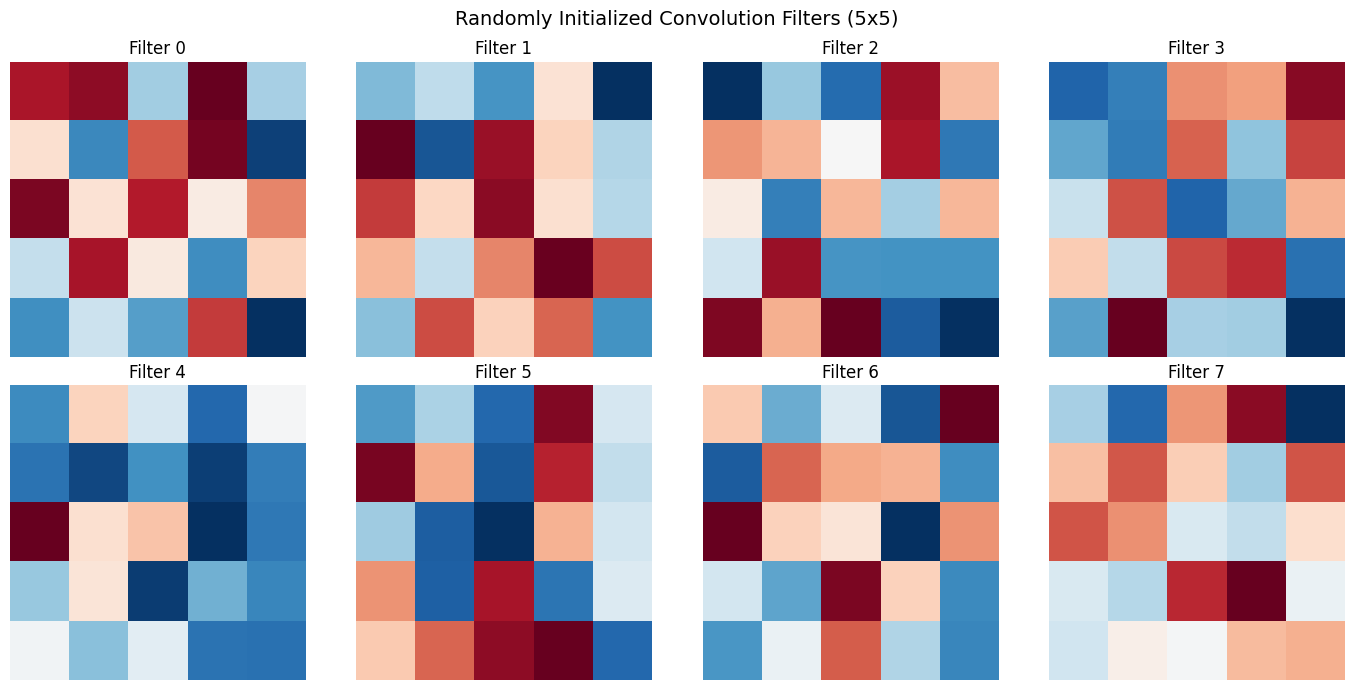

训练前：卷积核是随机的
训练后：卷积核会学到边缘、纹理等有意义的特征


In [9]:
# 可视化卷积核学到的特征
torch.manual_seed(42)

conv_layer = nn.Conv2d(1, 8, kernel_size=5, padding=2)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flatten()):
    kernel = conv_layer.weight[i, 0].detach().numpy()
    ax.imshow(kernel, cmap='RdBu_r')
    ax.set_title(f'Filter {i}')
    ax.axis('off')
plt.suptitle('Randomly Initialized Convolution Filters (5x5)', fontsize=14)
plt.tight_layout()
plt.show()

print("训练前：卷积核是随机的")
print("训练后：卷积核会学到边缘、纹理等有意义的特征")

---
## 4. 实战：CNN 手写数字分类

In [10]:
try:
    from torchvision import datasets, transforms
    from torch.utils.data import DataLoader
    has_torchvision = True
except ImportError:
    has_torchvision = False
    print("需要 torchvision: pip install torchvision")

if has_torchvision:
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    
    train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
    test_dataset = datasets.MNIST('./data', train=False, transform=transform)
    
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)
    
    print(f"训练集: {len(train_dataset)}, 测试集: {len(test_dataset)}")
    print(f"图片形状: {train_dataset[0][0].shape}")

100%|██████████| 9.91M/9.91M [00:03<00:00, 2.65MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 116kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.05MB/s]
100%|██████████| 4.54k/4.54k [00:00<?, ?B/s]

训练集: 60000, 测试集: 10000
图片形状: torch.Size([1, 28, 28])


In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),    # (B, 1, 28, 28) -> (B, 32, 28, 28)
            nn.ReLU(),
            nn.MaxPool2d(2),                     # (B, 32, 28, 28) -> (B, 32, 14, 14)
            nn.Conv2d(32, 64, 3, padding=1),   # (B, 32, 14, 14) -> (B, 64, 14, 14)
            nn.ReLU(),
            nn.MaxPool2d(2),                     # (B, 64, 14, 14) -> (B, 64, 7, 7)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),                        # (B, 64, 7, 7) -> (B, 3136)
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10),                  # 10个数字
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCNN()
print(model)

total_params = sum(p.numel() for p in model.parameters())
print(f"\n总参数量: {total_params:,}")

# 对比 MLP 的参数量
mlp_params = 784 * 256 + 256 * 128 + 128 * 10
print(f"同等规模 MLP 参数量: {mlp_params:,}")
print(f"CNN 参数更少，效果更好！")

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)

总参数量: 421,642
同等规模 MLP 参数量: 234,752
CNN 参数更少，效果更好！


In [12]:
if has_torchvision:
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    train_losses = []
    train_accs = []
    
    for epoch in range(5):
        model.train()
        epoch_loss = 0
        correct = 0
        total = 0
        
        for X_batch, y_batch in train_loader:
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item() * X_batch.size(0)
            correct += (logits.argmax(dim=1) == y_batch).sum().item()
            total += X_batch.size(0)
        
        avg_loss = epoch_loss / total
        acc = correct / total
        train_losses.append(avg_loss)
        train_accs.append(acc)
        print(f"Epoch {epoch+1}: loss={avg_loss:.4f}, accuracy={acc:.4f}")

Epoch 1: loss=0.1380, accuracy=0.9588
Epoch 2: loss=0.0427, accuracy=0.9865
Epoch 3: loss=0.0291, accuracy=0.9906
Epoch 4: loss=0.0207, accuracy=0.9935
Epoch 5: loss=0.0165, accuracy=0.9946


In [13]:
if has_torchvision:
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            logits = model(X_batch)
            correct += (logits.argmax(dim=1) == y_batch).sum().item()
            total += X_batch.size(0)
    
    test_acc = correct / total
    print(f"CNN 测试集准确率: {test_acc:.4f}")
    print("仅5个epoch就达到99%以上！CNN 在图像任务上远优于 MLP")

CNN 测试集准确率: 0.9879
仅5个epoch就达到99%以上！CNN 在图像任务上远优于 MLP


## 5. 可视化 CNN 特征图

看看 CNN 每一层学到了什么。

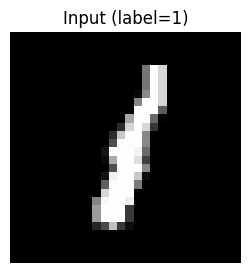

第1层卷积输出: torch.Size([1, 32, 28, 28])
第2层卷积输出: torch.Size([1, 64, 14, 14])


In [17]:
if has_torchvision:
    model.eval()
    sample_img, sample_label = test_dataset[89]
    x = sample_img.unsqueeze(0)  # (1, 1, 28, 28)
    
    plt.figure(figsize=(3, 3))
    plt.imshow(x.squeeze().numpy(), cmap='gray')
    plt.title(f'Input (label={sample_label})')
    plt.axis('off')
    plt.show()
    
    with torch.no_grad():
        conv1_out = model.features[0](x)        # 第1层卷积
        conv1_act = model.features[1](conv1_out) # 第1层ReLU
        pool1_out = model.features[2](conv1_act) # 第1层池化
        conv2_out = model.features[3](pool1_out) # 第2层卷积
        conv2_act = model.features[4](conv2_out) # 第2层ReLU
    
    print(f"第1层卷积输出: {conv1_out.shape}")
    print(f"第2层卷积输出: {conv2_out.shape}")

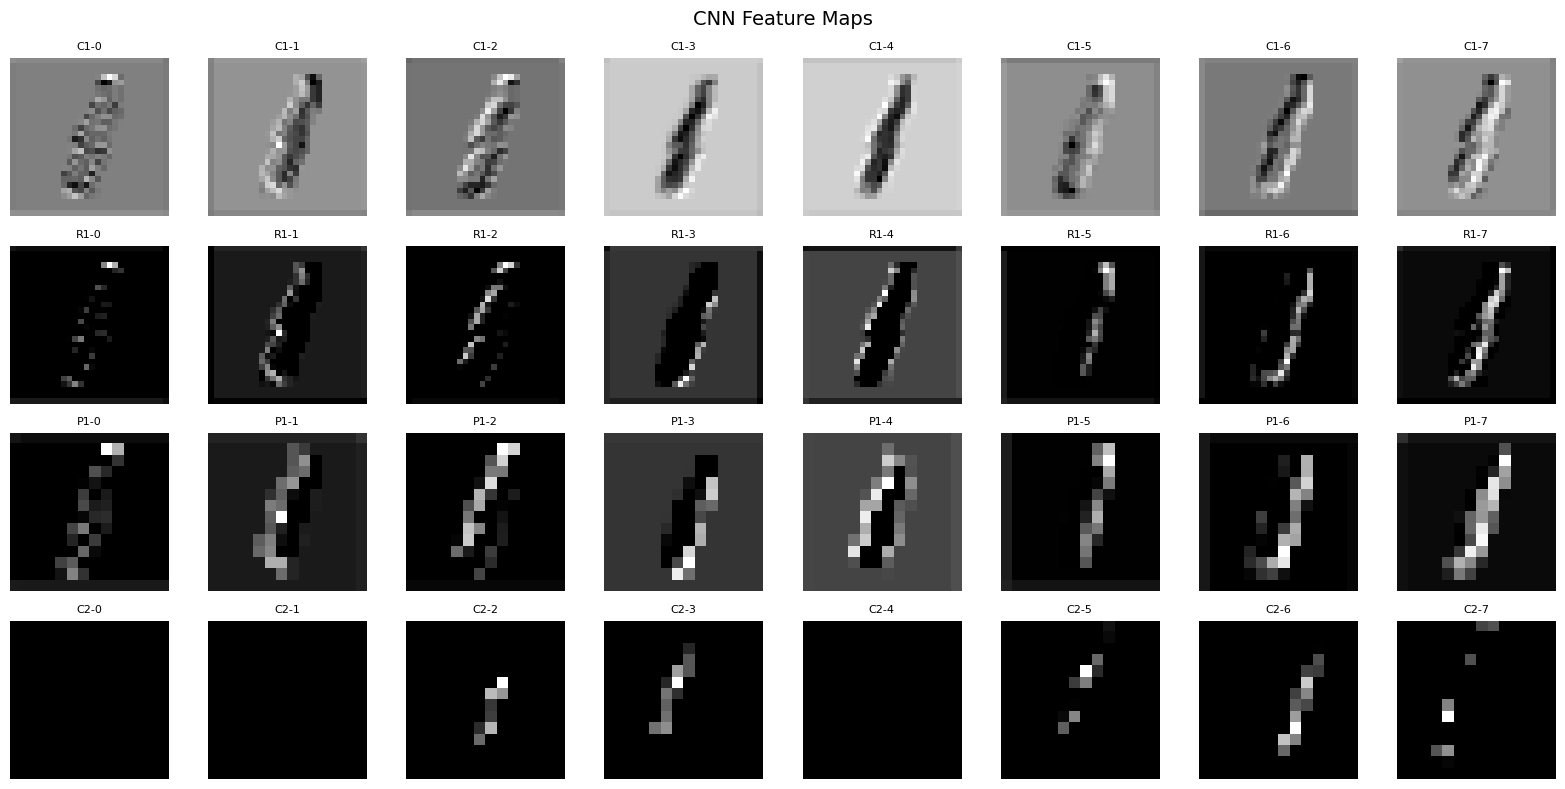

浅层特征图：检测边缘、线条等低级特征
深层特征图：检测更抽象的模式


In [18]:
if has_torchvision:
    fig, axes = plt.subplots(4, 8, figsize=(16, 8))
    
    for i in range(8):
        axes[0, i].imshow(conv1_out[0, i].numpy(), cmap='gray')
        axes[0, i].set_title(f'C1-{i}', fontsize=8)
        axes[0, i].axis('off')
        
        axes[1, i].imshow(conv1_act[0, i].numpy(), cmap='gray')
        axes[1, i].set_title(f'R1-{i}', fontsize=8)
        axes[1, i].axis('off')
        
        axes[2, i].imshow(pool1_out[0, i].numpy(), cmap='gray')
        axes[2, i].set_title(f'P1-{i}', fontsize=8)
        axes[2, i].axis('off')
        
        axes[3, i].imshow(conv2_act[0, i].numpy(), cmap='gray')
        axes[3, i].set_title(f'C2-{i}', fontsize=8)
        axes[3, i].axis('off')
    
    axes[0, 0].set_ylabel('Conv1', fontsize=10)
    axes[1, 0].set_ylabel('ReLU1', fontsize=10)
    axes[2, 0].set_ylabel('Pool1', fontsize=10)
    axes[3, 0].set_ylabel('Conv2+ReLU', fontsize=10)
    
    plt.suptitle('CNN Feature Maps', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    print("浅层特征图：检测边缘、线条等低级特征")
    print("深层特征图：检测更抽象的模式")

---
## 6. 经典 CNN 结构

In [19]:
# LeNet-5（1998，开山之作）
class LeNet5(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 6, 5, padding=2),   # 28x28 -> 28x28
            nn.Sigmoid(),
            nn.AvgPool2d(2),                   # 28x28 -> 14x14
            nn.Conv2d(6, 16, 5),              # 14x14 -> 10x10
            nn.Sigmoid(),
            nn.AvgPool2d(2),                   # 10x10 -> 5x5
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 5 * 5, 120),
            nn.Sigmoid(),
            nn.Linear(120, 84),
            nn.Sigmoid(),
            nn.Linear(84, 10),
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

lenet = LeNet5()
print("LeNet-5:")
print(lenet)
print(f"参数量: {sum(p.numel() for p in lenet.parameters()):,}")

LeNet-5:
LeNet5(
  (features): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): Sigmoid()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): Sigmoid()
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=400, out_features=120, bias=True)
    (2): Sigmoid()
    (3): Linear(in_features=120, out_features=84, bias=True)
    (4): Sigmoid()
    (5): Linear(in_features=84, out_features=10, bias=True)
  )
)
参数量: 61,706


In [ ]:
# VGG 风格的模块化设计
def make_vgg_block(in_ch, out_ch, num_convs):
    layers = []
    for _ in range(num_convs):
        layers.append(nn.Conv2d(in_ch, out_ch, 3, padding=1))
        layers.append(nn.ReLU())
        in_ch = out_ch
    layers.append(nn.MaxPool2d(2))
    return nn.Sequential(*layers)

class VGGLike(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            make_vgg_block(1, 32, 2),    # 28 -> 14
            make_vgg_block(32, 64, 2),   # 14 -> 7
            make_vgg_block(64, 128, 2),  # 7 -> 3
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 256),
            nn.ReLU(),
            nn.Linear(256, 10),
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

vgg = VGGLike()
print("VGG-style:")
print(vgg)
print(f"参数量: {sum(p.numel() for p in vgg.parameters()):,}")

In [ ]:
# ResNet 残差连接
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)
    
    def forward(self, x):
        residual = x
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += residual   # 残差连接！
        out = torch.relu(out)
        return out

class ResNetLike(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            ResidualBlock(32),
            ResidualBlock(32),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            ResidualBlock(64),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(64, 10),
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

resnet = ResNetLike()
print("ResNet-style:")
print(resnet)
print(f"参数量: {sum(p.numel() for p in resnet.parameters()):,}")

In [ ]:
# 残差连接的作用可视化
print("=== 残差连接为什么有效？ ===")
print()
print("没有残差连接: y = F(x)")
print("  梯度: dy/dx = dF/dx")
print("  如果 F 很深，梯度可能消失")
print()
print("有残差连接: y = F(x) + x")
print("  梯度: dy/dx = dF/dx + 1")
print("  即使 dF/dx 接近0，梯度至少为1")
print("  梯度可以"跳过"中间层直接回传！")
print()
print("这使得训练几十甚至上百层的网络成为可能")

## 7. 1x1 卷积与深度可分离卷积

In [ ]:
# 1x1 卷积：改变通道数，不改变空间尺寸
x = torch.randn(1, 64, 28, 28)

conv_1x1 = nn.Conv2d(64, 16, kernel_size=1)
out = conv_1x1(x)

print(f"1x1 卷积: {x.shape} -> {out.shape}")
print(f"参数量: {64 * 16} (64*16*1*1)")
print()
print("1x1 卷积的用途:")
print("  1. 降维/升维：改变通道数")
print("  2. 跨通道信息融合")
print("  3. 增加非线性（等价于逐像素的全连接层）")

In [ ]:
# 深度可分离卷积（MobileNet 核心）
x = torch.randn(1, 64, 28, 28)

# 标准卷积
std_conv = nn.Conv2d(64, 64, 3, padding=1)
std_params = sum(p.numel() for p in std_conv.parameters())

# 深度可分离卷积 = 深度卷积 + 逐点卷积
depthwise = nn.Conv2d(64, 64, 3, padding=1, groups=64)  # 每个通道单独卷积
pointwise = nn.Conv2d(64, 64, 1)                         # 1x1 融合通道
ds_params = sum(p.numel() for p in depthwise.parameters()) + sum(p.numel() for p in pointwise.parameters())

print(f"标准卷积参数量: {std_params:,}")
print(f"深度可分离卷积参数量: {ds_params:,}")
print(f"参数减少: {std_params / ds_params:.1f}x")
print()
print("深度可分离卷积大幅减少参数，适合移动端部署")

---
## 8. 经典 CNN 发展历程

In [ ]:
print("=== CNN 发展历程 ===")
print()
print("LeNet-5 (1998)     - 开山之作，7层，6万参数")
print("AlexNet (2012)     - 深度学习复兴，8层，6000万参数")
print("VGGNet (2014)      - 模块化设计，16-19层，1.4亿参数")
print("GoogLeNet (2014)   - Inception模块，22层，500万参数")
print("ResNet (2015)      - 残差连接，152层+，解决退化问题")
print("DenseNet (2017)    - 密集连接，特征复用")
print("EfficientNet (2019)- 复合缩放，精度效率平衡")
print("ConvNeXt (2022)    - 纯CNN挑战Transformer")
print()
print("趋势: 更深、更高效、更自动化")

---
## 总结

### CNN 核心组件

| 组件 | 作用 | 关键参数 |
|------|------|----------|
| Conv2d | 提取局部特征 | in/out_channels, kernel_size, stride, padding |
| ReLU | 引入非线性 | 无参数 |
| MaxPool2d | 降低尺寸，增强不变性 | kernel_size, stride |
| BatchNorm2d | 稳定训练 | num_features |
| AdaptiveAvgPool2d | 统一输出尺寸 | output_size |

### 输出尺寸公式
```
output = (input + 2*padding - kernel) // stride + 1
```

### CNN 设计模式
```
特征提取部分:                    分类部分:
  Conv -> BN -> ReLU -> Pool      Flatten -> Linear -> ReLU -> Linear
  Conv -> BN -> ReLU -> Pool      或
  ...                             AdaptiveAvgPool -> Flatten -> Linear
```

### 关键概念
- **卷积核**：学习局部特征的模式检测器
- **感受野**：输出像素对应的输入区域大小
- **残差连接**：解决深层网络梯度消失，使极深网络可训练
- **1x1 卷积**：改变通道数，跨通道融合
- **深度可分离卷积**：大幅减少参数量